In [12]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.6/169.6 kB 11.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyod: filename=pyod-2.0.3-py3-none-any.whl size=200466 sha256=ded9e9abef1e93811662b2b71cc51d791832d75465cb04a499f5abb5d65d7229
  Stored in directory: /root/.cache/pip/wheels/60/83/d0/cc2d3c992154f659eb68a8710537da31f50db28ff65a252189
Successfully built pyod


In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyod.models.mad import MAD
from pyod.models.iforest import IForest
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from statsmodels.tsa.seasonal import seasonal_decompose

In [106]:
financial_market_data_df = pd.read_csv('financial_market_data.csv', parse_dates=['Data'], index_col='Data')

financial_market_data_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1111 entries, 2000-01-11 to 2021-04-20
Data columns (total 43 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Y          1111 non-null   int64  
 1   XAU BGNL   1111 non-null   float64
 2   ECSURPUS   1111 non-null   float64
 3   BDIY       1111 non-null   float64
 4   CRY        1111 non-null   float64
 5   DXY        1111 non-null   float64
 6   JPY        1111 non-null   float64
 7   GBP        1111 non-null   float64
 8   Cl1        1111 non-null   float64
 9   VIX        1111 non-null   float64
 10  USGG30YR   1111 non-null   float64
 11  GT10       1111 non-null   float64
 12  USGG2YR    1111 non-null   float64
 13  USGG3M     1111 non-null   float64
 14  US0001M    1111 non-null   float64
 15  GTDEM30Y   1111 non-null   float64
 16  GTDEM10Y   1111 non-null   float64
 17  GTDEM2Y    1111 non-null   float64
 18  EONIA      1111 non-null   float64
 19  GTITL30YR  1111 non-null   flo

In [ ]:
financial_market_data_df.describe()

# Insight from the correlation matrix
I concluded VIX index is highly correlated to Y

In [107]:
financial_market_data_df.corr()

,Y,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,VIX,...,LP01TREU,EMUSTRUU,LF94TRUU,MXUS,MXEU,MXJP,MXBR,MXRU,MXIN,MXCN
Y,1.000000,-0.011535,-0.090772,-0.083440,-0.074102,0.103227,-0.151197,-0.093201,-0.070141,0.598432,...,-0.209774,-0.169475,-0.156550,-0.193928,-0.253877,-0.279399,-0.043429,-0.148848,-0.188942,-0.149581
XAU BGNL,-0.011535,1.000000,0.114798,-0.315007,0.015316,-0.428891,-0.576191,-0.422084,0.515215,-0.075873,...,0.817990,0.891486,0.925465,0.625814,0.176177,0.036654,0.581667,0.339929,0.831756,0.829659
ECSURPUS,-0.090772,0.114798,1.000000,-0.102022,-0.139779,0.074835,-0.070422,-0.188233,-0.016245,-0.094127,...,0.115747,0.110335,0.073268,0.192180,0.014535,0.034829,-0.014098,-0.077750,0.102198,0.115145
BDIY,-0.083440,-0.315007,-0.102022,1.000000,0.596182,-0.441793,0.062822,0.756718,0.286396,-0.045367,...,-0.410941,-0.350372,-0.241704,-0.300277,-0.058349,0.103124,0.337489,0.606526,-0.240799,-0.033084
CRY,-0.074102,0.015316,-0.139779,0.596182,1.000000,-0.798564,-0.412364,0.793954,0.785614,-0.190060,...,-0.315491,-0.218547,-0.045101,-0.458623,-0.261605,-0.235202,0.641511,0.761661,-0.210901,-0.031605
DXY,0.103227,-0.428891,0.074835,-0.441793,-0.798564,1.000000,0.650429,-0.544966,-0.816378,0.115712,...,-0.074069,-0.201703,-0.386866,0.144988,0.300674,0.247446,-0.776353,-0.756141,-0.188670,-0.352379
JPY,-0.151197,-0.576191,-0.070422,0.062822,-0.412364,0.650429,1.000000,-0.008633,-0.608209,-0.134791,...,-0.113902,-0.225936,-0.330176,0.115772,0.392934,0.557078,-0.639573,-0.306819,-0.149469,-0.269353
GBP,-0.093201,-0.422084,-0.188233,0.756718,0.793954,-0.544966,-0.008633,1.000000,0.352787,-0.124496,...,-0.598572,-0.549016,-0.402361,-0.594595,-0.246342,-0.113736,0.224720,0.530964,-0.501925,-0.329350
Cl1,-0.070141,0.515215,-0.016245,0.286396,0.785614,-0.816378,-0.608209,0.352787,1.000000,-0.213999,...,0.196312,0.292426,0.438823,-0.029697,-0.062125,-0.160278,0.861036,0.759998,0.284056,0.430908
VIX,0.598432,-0.075873,-0.094127,-0.045367,-0.190060,0.115712,-0.134791,-0.124496,-0.213999,1.000000,...,-0.310635,-0.253247,-0.227376,-0.239029,-0.421996,-0.367709,-0.098962,-0.247953,-0.243126,-0.164591


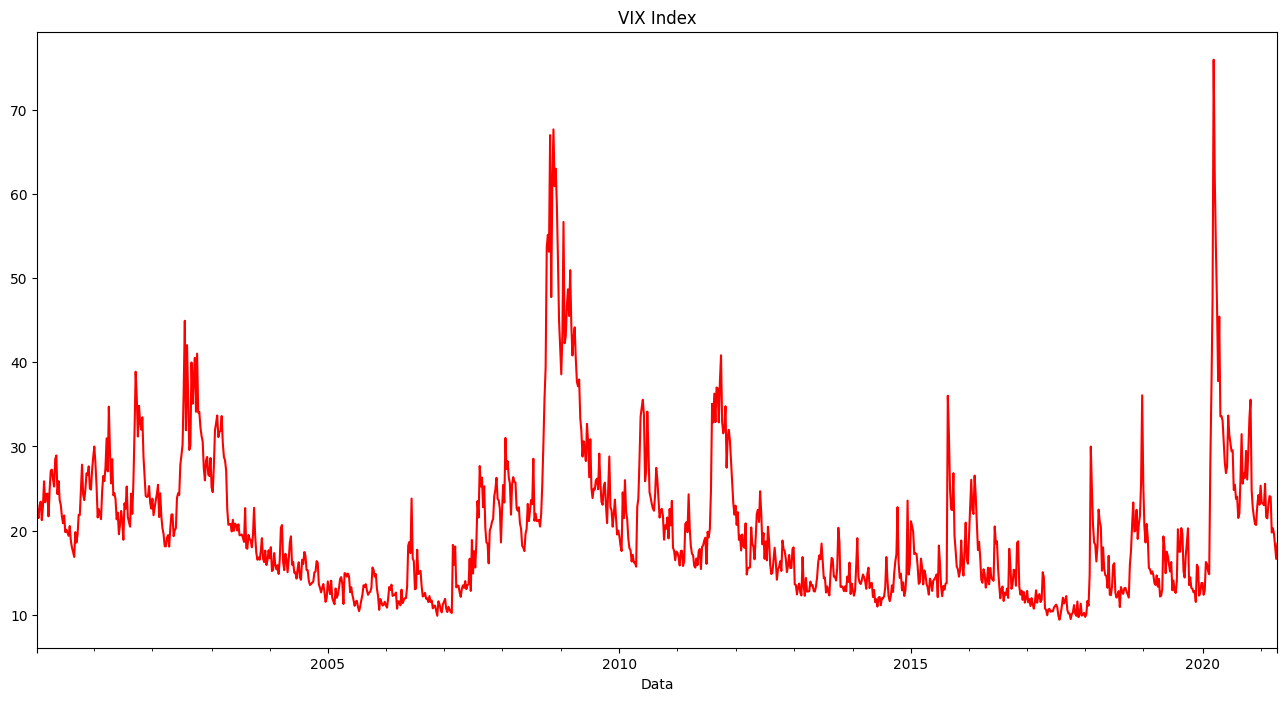

In [108]:
plt.figure(figsize=(16,8))
financial_market_data_df['VIX'].plot(color="red")
plt.title('VIX Index')
plt.show()

# Data Preprocessing

In [93]:
financial_market_data_df.dropna()

,Y,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,VIX,...,MXUS,MXEU,MXJP,MXBR,MXRU,MXIN,MXCN,day_of_week,month,day_of_month
Data,,,,,,,,,,,,,,,,,,,,,
2000-01-11,0,-1.428920,0.140025,-0.163616,-1.590073,1.011346,-0.333524,0.562796,-1.741368,0.537980,...,0.195473,0.760160,0.868966,-0.844876,-1.529558,-0.907315,-0.555749,1,1,11
2000-01-18,0,-1.366822,0.038901,-0.134645,-1.429500,1.064889,-0.381675,0.510631,-1.232189,0.421191,...,0.229147,0.887689,0.896178,-0.735295,-1.441021,-0.867197,-0.590495,1,1,18
2000-01-25,0,-1.384628,0.307111,-0.183617,-1.362146,1.078939,-0.314752,0.584984,-1.291769,0.608973,...,0.142657,0.676389,0.748473,-0.776770,-1.621589,-0.848075,-0.603433,1,1,25
2000-02-01,0,-1.441921,0.466803,-0.246586,-1.369503,1.127353,-0.106610,0.360172,-1.307697,0.655617,...,0.140377,0.866189,1.026893,-0.871787,-1.762589,-0.827514,-0.624898,1,2,1
2000-02-08,1,-1.276484,0.791455,-0.281378,-1.410319,1.110909,0.079120,0.360172,-1.320100,0.396227,...,0.190964,1.372829,1.257377,-0.730602,-1.606755,-0.748331,-0.623797,1,2,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-03-23,0,1.573340,0.838406,0.511424,-0.680471,0.162823,-0.001255,-0.822593,0.011291,0.270485,...,2.477194,2.202248,2.768310,-0.220279,0.232106,2.623862,2.328419,1,3,23
2021-03-30,0,1.407618,0.772677,0.416318,-0.671412,0.221964,0.234219,-0.831389,0.131837,0.204638,...,2.581885,2.528965,2.906290,-0.288376,0.277125,2.525066,2.233443,1,3,30
2021-04-06,0,1.659176,1.094069,0.406079,-0.630836,0.162024,0.172731,-0.807153,0.081638,0.026760,...,2.899469,2.898701,2.536802,-0.202880,0.207330,2.506229,2.402314,1,4,6


In [96]:
financial_market_data_df.sort_index()
X = financial_market_data_df.drop('Y', axis=1)
y = financial_market_data_df['Y']

tss = TimeSeriesSplit(n_splits=2)

for train_index, test_index in tss.split(X):
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

TRAIN: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244

In [94]:
mad = MAD().fit(financial_market_data_df[['VIX']])
is_outlier = mad.labels_ == 1
print(len(financial_market_data_df[is_outlier]))

2


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [90]:
cfm = confusion_matrix(financial_market_data_df['Y'], is_outlier)
print(cfm)

[[873   1]
 [236   1]]


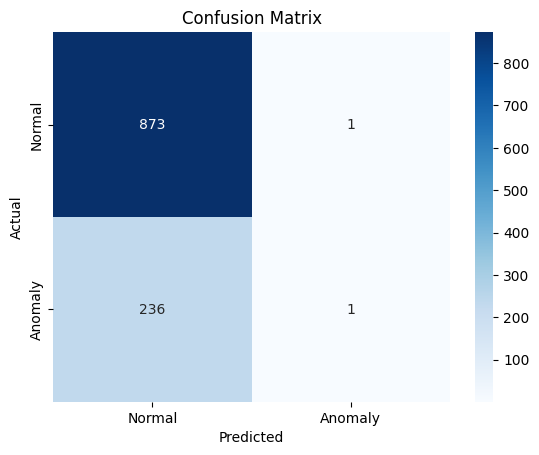

In [91]:
sns.heatmap(cfm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [15]:
# Adding new columns to our pre-existing features

financial_market_data_df['day_of_week'] = financial_market_data_df.index.day_of_week
financial_market_data_df['month'] = financial_market_data_df.index.month
financial_market_data_df['day_of_month'] = financial_market_data_df.index.day

financial_market_data_df.head()

,Y,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,VIX,...,MXUS,MXEU,MXJP,MXBR,MXRU,MXIN,MXCN,day_of_week,month,day_of_month
Data,,,,,,,,,,,,,,,,,,,,,
2000-01-11,0,283.25,0.077,1388.0,157.26,100.56,105.86,1.646,25.77,22.50,...,1416.12,127.75,990.59,856.76,224.33,217.34,34.30,1,1,11
2000-01-18,0,287.65,0.043,1405.0,165.01,101.86,105.47,1.638,28.85,21.50,...,1428.79,129.50,993.98,925.22,234.37,227.08,32.74,1,1,18
2000-01-25,0,287.15,0.135,1368.0,167.24,102.41,106.04,1.650,28.28,23.02,...,1385.93,126.48,974.83,886.93,216.82,233.00,32.46,1,1,25
2000-02-01,0,282.75,0.191,1311.0,166.85,104.92,107.85,1.611,28.22,23.45,...,1385.31,129.19,1007.12,842.60,201.89,237.48,31.29,1,2,1
2000-02-08,1,298.40,0.312,1277.0,165.43,104.22,109.30,1.611,28.02,21.25,...,1411.95,134.67,1034.58,945.15,218.00,258.02,31.32,1,2,8


In [16]:
from pyod.models.iforest import IForest

In [72]:
iforest = IForest().fit(financial_market_data_df)

probs = iforest.predict_proba(financial_market_data_df)
is_outlier = probs[:,1] > 0.7
print(len(financial_market_data_df[is_outlier]))

48


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


In [73]:
cfm = confusion_matrix(financial_market_data_df['Y'], is_outlier)
print(cfm)

[[845  29]
 [218  19]]


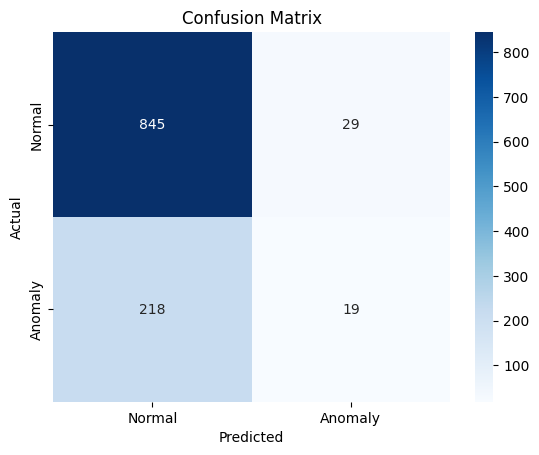

In [74]:
sns.heatmap(cfm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [19]:
# To get better result and let's use VIX index in combination with day_of_week, month and day_of_month
new_features = financial_market_data_df[['VIX', 'day_of_week', 'month', 'day_of_month']]
new_features.head()

,VIX,day_of_week,month,day_of_month
Data,,,,
2000-01-11,22.50,1,1,11
2000-01-18,21.50,1,1,18
2000-01-25,23.02,1,1,25
2000-02-01,23.45,1,2,1
2000-02-08,21.25,1,2,8


In [24]:
iforest = IForest().fit(new_features)

probs = iforest.predict_proba(new_features)
is_outlier = probs[:,1] > 0.7
print(len(new_features[is_outlier]))

19


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


# Feature Engineering

In [ ]:
def

# Decomposition

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

results = seasonal_decompose(financial_market_data_df['VIX'], period=365)
print(results)

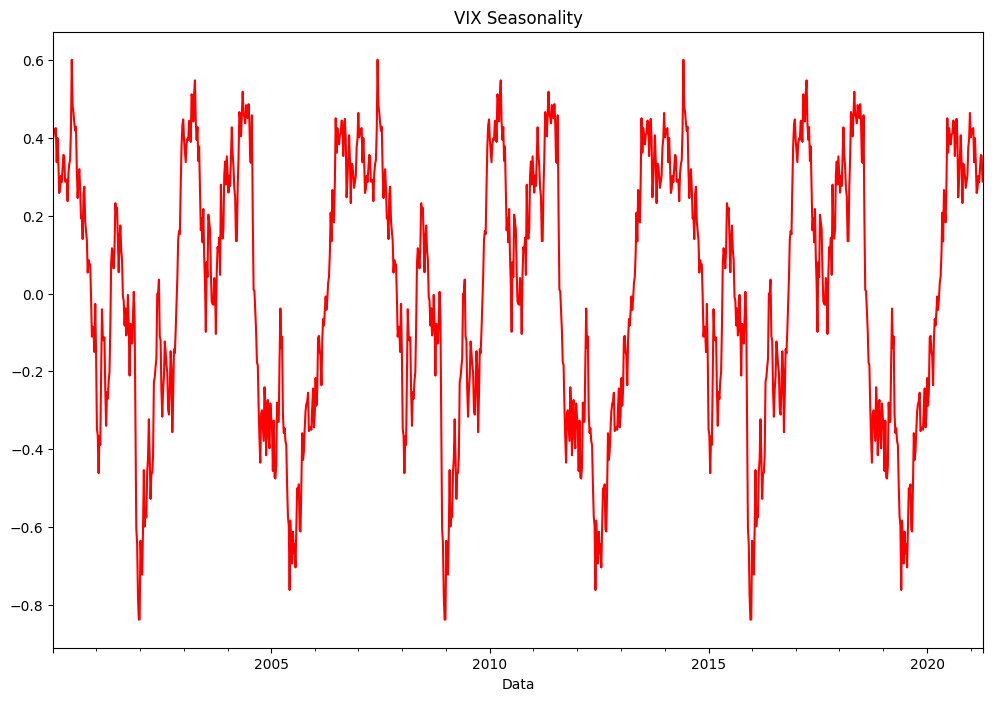

In [32]:
results.seasonal.plot(color='red', figsize=(12,8))
plt.title('VIX Seasonality')
plt.show()

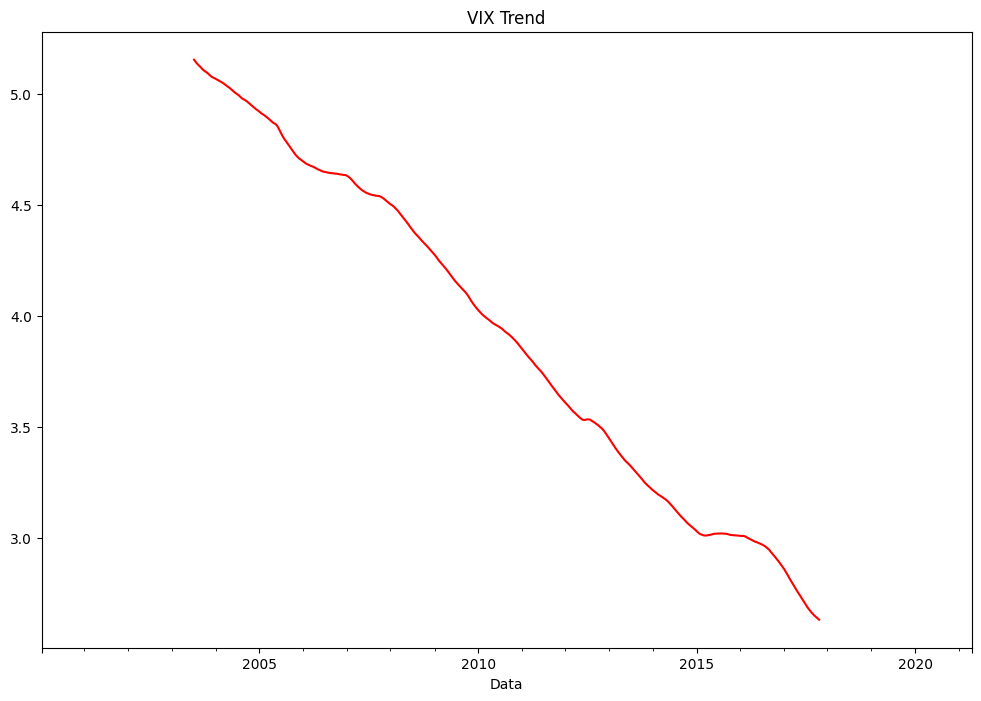

In [33]:
results.trend.plot(color='red', figsize=(12,8))
plt.title('VIX Trend')
plt.show()

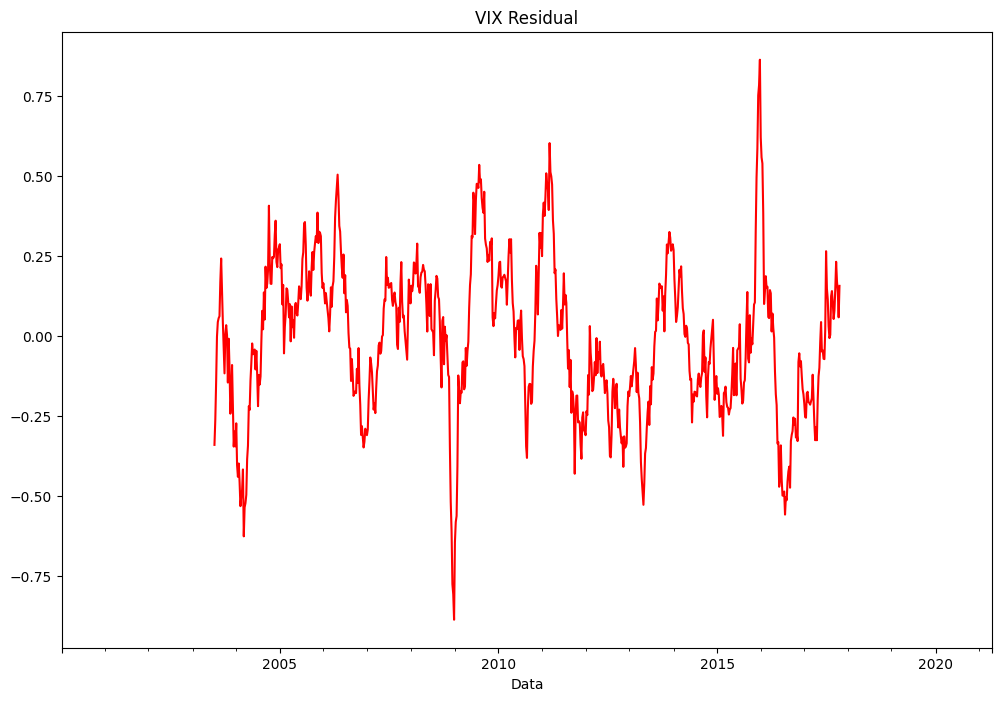

In [34]:
results.resid.plot(color='red', figsize=(12,8))
plt.title('VIX Residual')
plt.show()

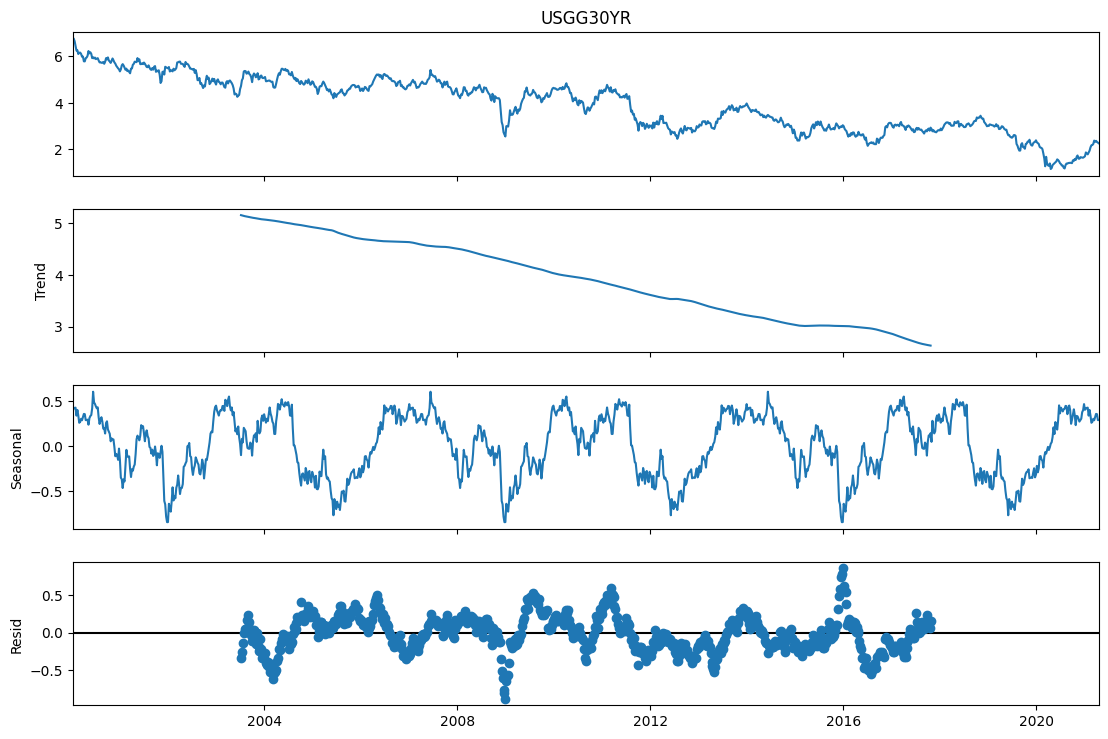

In [35]:
figure = results.plot()

figure.set_figwidth(12)
figure.set_figheight(8)

Seasonal decomposition for USGG30YR

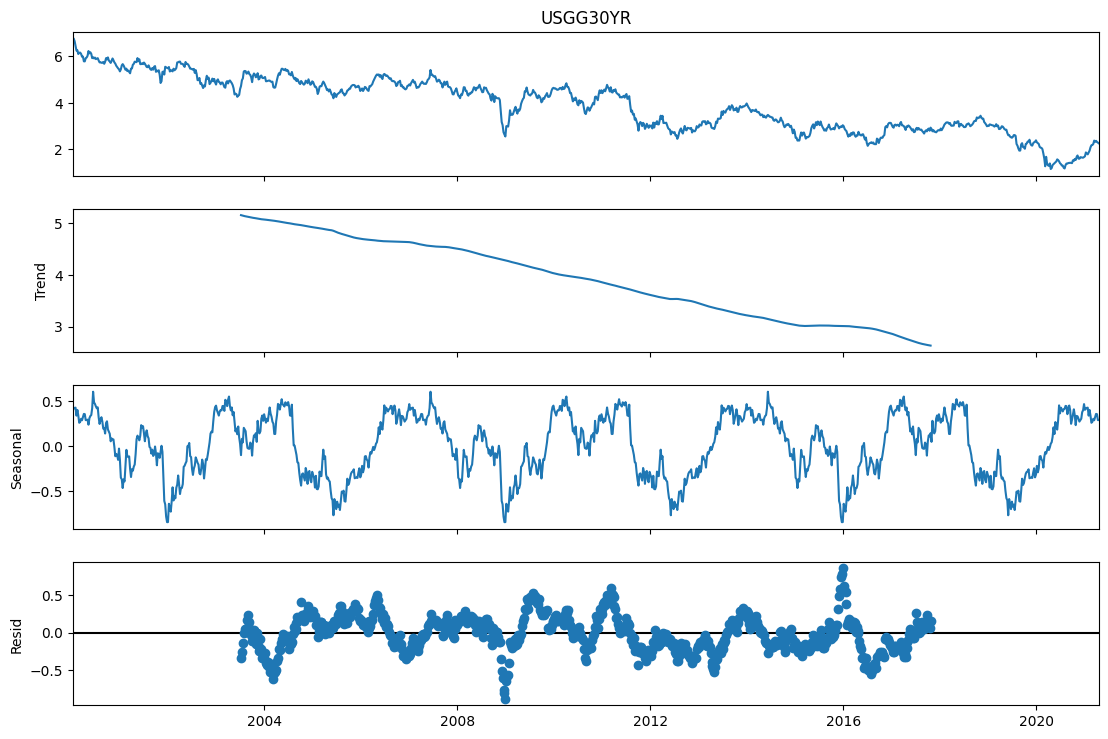

In [36]:
results = seasonal_decompose(financial_market_data_df['USGG30YR'], period=365)
figure = results.plot()
figure.set_figwidth(12)
figure.set_figheight(8)

In [37]:
# Extract and reshape residuals
results = seasonal_decompose(financial_market_data_df['VIX'], period=365)
residuals = results.resid.values.reshape(-1,1)

# Fit MAD
mad = MAD().fit(residuals)

# Find the outliers
is_outlier = mad.labels_ == 1
outliers = financial_market_data_df[is_outlier]
print(len(outliers))

22


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


# Ensemble
Using Ensemble let's find mean for our outlier from different model's prediction

In [45]:
from sklearn.preprocessing import QuantileTransformer
from pyod.models.knn import KNN
from pyod.models.lof import LOF
import numpy as np

In [97]:
to_scale = ["XAU BGNL", "ECSURPUS", "BDIY", "CRY", "DXY", "JPY", "GBP", "Cl1", "VIX",
    "USGG30YR", "GT10", "USGG2YR", "USGG3M", "US0001M", "GTDEM30Y", "GTDEM10Y",
    "GTDEM2Y", "EONIA", "GTITL30YR", "GTITL10YR", "GTITL2YR", "GTJPY30YR",
    "GTJPY10YR", "GTJPY2YR", "GTGBP30Y", "GTGBP20Y", "GTGBP2Y", "LUMSTRUU",
    "LMBITR", "LUACTRUU", "LF98TRUU", "LG30TRUU", "LP01TREU", "EMUSTRUU",
    "LF94TRUU", "MXUS", "MXEU", "MXJP", "MXBR", "MXRU", "MXIN", "MXCN"]
transformer = QuantileTransformer(output_distribution='normal')
financial_market_data_df.loc[:, to_scale] = transformer.fit_transform(financial_market_data_df[to_scale])

In [98]:
estimators = [KNN(n_neighbors=20), LOF(n_neighbors=20), IForest()]

shape = (len(financial_market_data_df), len(estimators))
probability_scores = np.empty(shape=shape)

for index, estimator in enumerate(estimators):
    estimator.fit(financial_market_data_df)
    probs = estimator.predict_proba(financial_market_data_df)
    probability_scores[:, index] = probs[:,1]

mean_scores = np.mean(probability_scores, axis=1)
mean_scores

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


array([0.56652887, 0.84948254, 0.52700661, ..., 0.57087213, 0.56037212,
       0.84111849])

In [99]:
is_outlier = mean_scores > 0.75
outliers = financial_market_data_df[is_outlier]
print(len(outliers))

6


In [100]:
cfm = confusion_matrix(financial_market_data_df['Y'], is_outlier)
print(cfm)

[[868   6]
 [237   0]]


Would it make a difference if I only choose VIX and USGG30YR

In [101]:
to_scale = ["VIX", "USGG30YR"]
transformer = QuantileTransformer(output_distribution='normal')
financial_market_data_df.loc[:, to_scale] = transformer.fit_transform(financial_market_data_df[to_scale])

In [102]:
estimators = [KNN(n_neighbors=20), LOF(n_neighbors=20), IForest()]

shape = (len(new_features), len(estimators))
probability_scores = np.empty(shape=shape)

for index, estimator in enumerate(estimators):
    estimator.fit(new_features)
    probs = estimator.predict_proba(new_features)
    probability_scores[:, index] = probs[:,1]

mean_scores = np.mean(probability_scores, axis=1)
mean_scores

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


array([0.15881212, 0.1406932 , 0.16126959, ..., 0.06750655, 0.03945993,
       0.03633766])

In [103]:
is_outlier = mean_scores > 0.75
outliers = financial_market_data_df[is_outlier]
print(len(outliers))

4


# Testing the performance of the prediction

In [104]:
cfm = confusion_matrix(financial_market_data_df['Y'], is_outlier)
print(cfm)

[[874   0]
 [233   4]]


In [105]:
clr = classification_report(financial_market_data_df['Y'], is_outlier)
print(clr)

              precision    recall  f1-score   support

           0       0.79      1.00      0.88       874
           1       1.00      0.02      0.03       237

    accuracy                           0.79      1111
   macro avg       0.89      0.51      0.46      1111
weighted avg       0.83      0.79      0.70      1111



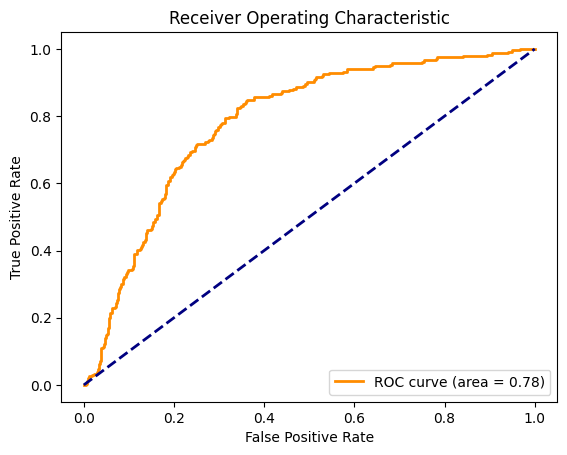

In [85]:
fpr, tpr, thresholds = roc_curve(financial_market_data_df['Y'], mean_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

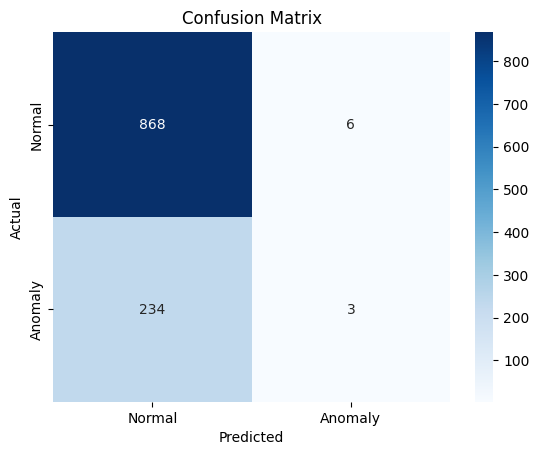

In [86]:
sns.heatmap(cfm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()